In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None


In [2]:
test = pd.read_csv('/kaggle/input/oemc-hackathon-global-fapar-modeling/test.csv')
test.head() 

,sample_id,station,month,modis_blue,modis_red,modis_nir,modis_mir,modis_evi,modis_ndvi,modis_lst_day_p05,modis_lst_day_p50,modis_lst_day_p95,modis_lst_night_p05,modis_lst_night_p50,modis_lst_night_p95,wv_yearly_p25,wv_yearly_p50,wv_yearly_p75,wv_monthly_lt_p50,wv_monthly_lt_p25,wv_monthly_lt_p75,wv_monthly_lt_sd,wv_monthly_ts_raw,wv_monthly_ts_smooth,accum_pr_monthly,dtm_slope,dtm_aspect-cosine,dtm_aspect-sine,dtm_downlslope.curvature,dtm_upslope.curvature,dtm_elevation,dtm_cti,dtm_neg.openess,dtm_pos.openess,dtm_vbf
0,0,36,12,692.0,1835.0,2632.0,2512.0,1108.0,1786.0,13600.0,13992.0,14480.0,13600.0,13200.0,13560.0,495.0,557.0,760.0,426.0,404.0,447.0,32.0,399.0,429.0,1808.0,2.0,-979.0,-994.0,5.0,1.0,1802.0,-765.0,156.0,156.0,25.0
1,1,93,1,311.0,475.0,1405.0,480.0,2051.0,4996.0,12600.0,12768.0,13224.0,12600.0,12928.0,13120.0,567.0,906.0,1921.0,456.0,400.0,507.0,78.0,389.0,366.0,499.0,1.0,-2801.0,-847.0,1.0,2.0,218.0,2483.0,157.0,157.0,837.0
2,2,77,3,286.0,1155.0,2272.0,702.0,1637.0,3260.0,14904.0,14904.0,14904.0,14904.0,14632.0,14640.0,2785.0,3009.0,3189.0,3693.0,3534.0,3856.0,293.0,3702.0,3253.0,4778.0,12.0,4961.0,675.0,4.0,51.0,735.0,-2462.0,150.0,156.0,0.0
3,3,51,7,959.0,1884.0,2748.0,3016.0,1283.0,1934.0,15968.0,16144.0,16280.0,15968.0,14912.0,15032.0,705.0,828.0,1398.0,2383.0,1906.0,2539.0,538.0,2537.0,2104.0,6690.0,2.0,6952.0,-718.0,-3.0,-1.0,992.0,1547.0,156.0,156.0,116.0
4,4,31,10,384.0,622.0,4216.0,879.0,5860.0,7332.0,15128.0,15248.0,15288.0,15128.0,14744.0,14784.0,3309.0,3850.0,4149.0,4118.0,3984.0,4359.0,280.0,4099.0,4139.0,9001.0,1.0,-3561.0,920.0,-1.0,-1.0,20.0,64.0,157.0,156.0,300.0


In [3]:
train = pd.read_csv('/kaggle/input/oemc-hackathon-global-fapar-modeling/train.csv')
train.head()

,sample_id,station,month,fapar,modis_blue,modis_red,modis_nir,modis_mir,modis_evi,modis_ndvi,modis_lst_day_p05,modis_lst_day_p50,modis_lst_day_p95,modis_lst_night_p05,modis_lst_night_p50,modis_lst_night_p95,wv_yearly_p25,wv_yearly_p50,wv_yearly_p75,wv_monthly_lt_p50,wv_monthly_lt_p25,wv_monthly_lt_p75,wv_monthly_lt_sd,wv_monthly_ts_raw,wv_monthly_ts_smooth,accum_pr_monthly,dtm_slope,dtm_aspect-cosine,dtm_aspect-sine,dtm_downlslope.curvature,dtm_upslope.curvature,dtm_elevation,dtm_cti,dtm_neg.openess,dtm_pos.openess,dtm_vbf
0,0,52,2,0.310634,235.0,545.0,1306.0,1414.0,1484.0,4108.0,13656.0,14032.0,14384.0,13656.0,13600.0,13760.0,696.0,1531.0,2191.0,513.0,454.0,568.0,123.0,569.0,479.0,8220.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
1,1,14,9,0.699500,355.0,531.0,3348.0,786.0,5060.0,7156.0,14904.0,15200.0,15296.0,14904.0,14840.0,14864.0,3179.0,3431.0,3805.0,3915.0,3747.0,4285.0,347.0,4222.0,4081.0,780.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0
2,2,52,3,0.353572,276.0,642.0,1496.0,1364.0,1614.0,4086.0,14400.0,14480.0,14888.0,14400.0,13888.0,14112.0,716.0,1223.0,2287.0,625.0,518.0,713.0,135.0,773.0,734.0,383.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
3,3,73,11,0.260067,519.0,1196.0,3256.0,1247.0,3112.0,4628.0,13264.0,13696.0,13976.0,13264.0,13192.0,13664.0,577.0,806.0,1846.0,544.0,503.0,650.0,98.0,640.0,771.0,1358.0,1.0,5685.0,788.0,0.0,0.0,584.0,3795.0,157.0,157.0,257.0
4,4,14,3,0.779333,327.0,528.0,3106.0,988.0,4572.0,7048.0,15136.0,15200.0,15296.0,15136.0,14736.0,14800.0,3130.0,3625.0,4024.0,2815.0,2660.0,2974.0,238.0,2977.0,2961.0,1226.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0


In [4]:
combined = pd.concat([train,test])
combined.head()

,sample_id,station,month,fapar,modis_blue,modis_red,modis_nir,modis_mir,modis_evi,modis_ndvi,modis_lst_day_p05,modis_lst_day_p50,modis_lst_day_p95,modis_lst_night_p05,modis_lst_night_p50,modis_lst_night_p95,wv_yearly_p25,wv_yearly_p50,wv_yearly_p75,wv_monthly_lt_p50,wv_monthly_lt_p25,wv_monthly_lt_p75,wv_monthly_lt_sd,wv_monthly_ts_raw,wv_monthly_ts_smooth,accum_pr_monthly,dtm_slope,dtm_aspect-cosine,dtm_aspect-sine,dtm_downlslope.curvature,dtm_upslope.curvature,dtm_elevation,dtm_cti,dtm_neg.openess,dtm_pos.openess,dtm_vbf
0,0,52,2,0.310634,235.0,545.0,1306.0,1414.0,1484.0,4108.0,13656.0,14032.0,14384.0,13656.0,13600.0,13760.0,696.0,1531.0,2191.0,513.0,454.0,568.0,123.0,569.0,479.0,8220.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
1,1,14,9,0.699500,355.0,531.0,3348.0,786.0,5060.0,7156.0,14904.0,15200.0,15296.0,14904.0,14840.0,14864.0,3179.0,3431.0,3805.0,3915.0,3747.0,4285.0,347.0,4222.0,4081.0,780.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0
2,2,52,3,0.353572,276.0,642.0,1496.0,1364.0,1614.0,4086.0,14400.0,14480.0,14888.0,14400.0,13888.0,14112.0,716.0,1223.0,2287.0,625.0,518.0,713.0,135.0,773.0,734.0,383.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
3,3,73,11,0.260067,519.0,1196.0,3256.0,1247.0,3112.0,4628.0,13264.0,13696.0,13976.0,13264.0,13192.0,13664.0,577.0,806.0,1846.0,544.0,503.0,650.0,98.0,640.0,771.0,1358.0,1.0,5685.0,788.0,0.0,0.0,584.0,3795.0,157.0,157.0,257.0
4,4,14,3,0.779333,327.0,528.0,3106.0,988.0,4572.0,7048.0,15136.0,15200.0,15296.0,15136.0,14736.0,14800.0,3130.0,3625.0,4024.0,2815.0,2660.0,2974.0,238.0,2977.0,2961.0,1226.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8400 entries, 0 to 4938
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sample_id                 8400 non-null   int64  
 1   station                   8400 non-null   int64  
 2   month                     8400 non-null   int64  
 3   fapar                     3461 non-null   float64
 4   modis_blue                8400 non-null   float64
 5   modis_red                 8400 non-null   float64
 6   modis_nir                 8400 non-null   float64
 7   modis_mir                 8400 non-null   float64
 8   modis_evi                 8400 non-null   float64
 9   modis_ndvi                8400 non-null   float64
 10  modis_lst_day_p05         8400 non-null   float64
 11  modis_lst_day_p50         8400 non-null   float64
 12  modis_lst_day_p95         8400 non-null   float64
 13  modis_lst_night_p05       8400 non-null   float64
 14  modis_lst_nig

In [6]:
combined.dtypes

sample_id                     int64
station                       int64
month                         int64
fapar                       float64
modis_blue                  float64
modis_red                   float64
modis_nir                   float64
modis_mir                   float64
modis_evi                   float64
modis_ndvi                  float64
modis_lst_day_p05           float64
modis_lst_day_p50           float64
modis_lst_day_p95           float64
modis_lst_night_p05         float64
modis_lst_night_p50         float64
modis_lst_night_p95         float64
wv_yearly_p25               float64
wv_yearly_p50               float64
wv_yearly_p75               float64
wv_monthly_lt_p50           float64
wv_monthly_lt_p25           float64
wv_monthly_lt_p75           float64
wv_monthly_lt_sd            float64
wv_monthly_ts_raw           float64
wv_monthly_ts_smooth        float64
accum_pr_monthly            float64
dtm_slope                   float64
dtm_aspect-cosine           

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
sample_id,8400.0,2164.514405,1318.726876,0.0,1049.750000,2099.500000,3149.2500,4938.000000
station,8400.0,55.838214,30.866105,1.0,29.000000,56.000000,84.0000,103.000000
month,8400.0,6.565238,3.408880,1.0,4.000000,7.000000,9.0000,12.000000
fapar,3461.0,0.445285,0.386978,0.0,0.025787,0.471319,0.8517,0.994801
modis_blue,8400.0,485.211905,690.478621,2.0,177.750000,292.000000,584.2500,9400.000000
modis_red,8400.0,918.181071,1059.676361,20.0,312.000000,535.500000,1093.0000,7104.000000
modis_nir,8400.0,2688.594167,998.482580,434.0,2028.000000,2506.000000,3080.0000,6336.000000
modis_mir,8400.0,1494.744405,1454.712010,162.0,600.000000,962.000000,1826.0000,7780.000000
modis_evi,8400.0,3166.058690,1693.592459,-967.0,1690.000000,2992.000000,4444.0000,8240.000000
modis_ndvi,8400.0,5514.770357,2554.614587,-574.0,3179.000000,6036.000000,7768.0000,9824.000000


In [8]:
combined.columns

Index(['sample_id', 'station', 'month', 'fapar', 'modis_blue', 'modis_red',
       'modis_nir', 'modis_mir', 'modis_evi', 'modis_ndvi',
       'modis_lst_day_p05', 'modis_lst_day_p50', 'modis_lst_day_p95',
       'modis_lst_night_p05', 'modis_lst_night_p50', 'modis_lst_night_p95',
       'wv_yearly_p25', 'wv_yearly_p50', 'wv_yearly_p75', 'wv_monthly_lt_p50',
       'wv_monthly_lt_p25', 'wv_monthly_lt_p75', 'wv_monthly_lt_sd',
       'wv_monthly_ts_raw', 'wv_monthly_ts_smooth', 'accum_pr_monthly',
       'dtm_slope', 'dtm_aspect-cosine', 'dtm_aspect-sine',
       'dtm_downlslope.curvature', 'dtm_upslope.curvature', 'dtm_elevation',
       'dtm_cti', 'dtm_neg.openess', 'dtm_pos.openess', 'dtm_vbf'],
      dtype='object')

In [9]:
combined.shape

(8400, 36)

In [10]:
combined.skew()

sample_id                   0.234884
station                    -0.169099
month                      -0.033356
fapar                       0.044813
modis_blue                  7.766240
modis_red                   2.709008
modis_nir                   1.361609
modis_mir                   2.350576
modis_evi                   0.380744
modis_ndvi                 -0.364810
modis_lst_day_p05          -0.633832
modis_lst_day_p50          -0.545811
modis_lst_day_p95          -0.395299
modis_lst_night_p05        -0.633832
modis_lst_night_p50        -0.755988
modis_lst_night_p95        -0.900496
wv_yearly_p25               1.762078
wv_yearly_p50               1.378804
wv_yearly_p75               0.517323
wv_monthly_lt_p50           0.798884
wv_monthly_lt_p25           0.840779
wv_monthly_lt_p75           0.773664
wv_monthly_lt_sd            0.781342
wv_monthly_ts_raw           0.865805
wv_monthly_ts_smooth        0.782223
accum_pr_monthly            2.846704
dtm_slope                   1.199685
d

In [11]:
combined.kurt()

sample_id                   -0.928431
station                     -1.245101
month                       -1.185569
fapar                       -1.733953
modis_blue                  88.124822
modis_red                    7.326340
modis_nir                    2.122674
modis_mir                    5.586743
modis_evi                   -0.762955
modis_ndvi                  -1.149821
modis_lst_day_p05            0.141851
modis_lst_day_p50            0.448164
modis_lst_day_p95            0.685799
modis_lst_night_p05          0.141851
modis_lst_night_p50          0.280243
modis_lst_night_p95          0.587228
wv_yearly_p25                2.328249
wv_yearly_p50                1.341472
wv_yearly_p75               -0.504855
wv_monthly_lt_p50           -0.411654
wv_monthly_lt_p25           -0.340719
wv_monthly_lt_p75           -0.438983
wv_monthly_lt_sd             0.072970
wv_monthly_ts_raw           -0.158937
wv_monthly_ts_smooth        -0.327042
accum_pr_monthly            10.638351
dtm_slope   

In [12]:
combined.tail()

,sample_id,station,month,fapar,modis_blue,modis_red,modis_nir,modis_mir,modis_evi,modis_ndvi,modis_lst_day_p05,modis_lst_day_p50,modis_lst_day_p95,modis_lst_night_p05,modis_lst_night_p50,modis_lst_night_p95,wv_yearly_p25,wv_yearly_p50,wv_yearly_p75,wv_monthly_lt_p50,wv_monthly_lt_p25,wv_monthly_lt_p75,wv_monthly_lt_sd,wv_monthly_ts_raw,wv_monthly_ts_smooth,accum_pr_monthly,dtm_slope,dtm_aspect-cosine,dtm_aspect-sine,dtm_downlslope.curvature,dtm_upslope.curvature,dtm_elevation,dtm_cti,dtm_neg.openess,dtm_pos.openess,dtm_vbf
4934,4934,95,9,NaN,169.0,262.0,2556.0,435.0,4560.0,8056.0,14256.0,14488.0,14712.0,14256.0,14160.0,14424.0,881.0,1212.0,2009.0,1823.0,1629.0,1936.0,240.0,1930.0,1981.0,6516.0,3.0,981.0,989.0,-3.0,-4.0,21.0,-207.0,157.0,155.0,626.0
4935,4935,29,11,NaN,469.0,1145.0,2062.0,1793.0,1522.0,2882.0,14272.0,14400.0,14784.0,14272.0,13656.0,14024.0,779.0,1193.0,2556.0,788.0,728.0,889.0,117.0,788.0,967.0,149.0,2.0,9208.0,311.0,-5.0,-3.0,325.0,676.0,157.0,156.0,269.0
4936,4936,90,9,NaN,179.0,346.0,2136.0,796.0,3468.0,7212.0,14104.0,14528.0,14808.0,14104.0,13880.0,14256.0,347.0,525.0,1487.0,1188.0,1059.0,1283.0,136.0,1133.0,1477.0,5819.0,3.0,8620.0,-478.0,-4.0,-3.0,265.0,-2551.0,156.0,155.0,168.0
4937,4937,85,2,NaN,216.0,406.0,2556.0,707.0,4004.0,7256.0,14784.0,14864.0,14976.0,14784.0,14320.0,14408.0,1380.0,1661.0,1875.0,2089.0,1955.0,2131.0,182.0,2094.0,2021.0,192.0,2.0,9674.0,-147.0,-2.0,6.0,9.0,-1634.0,157.0,156.0,579.0
4938,4938,27,2,NaN,618.0,1188.0,1987.0,1962.0,1382.0,2540.0,13808.0,14160.0,14576.0,13808.0,13480.0,13808.0,831.0,1283.0,2287.0,596.0,546.0,711.0,96.0,635.0,638.0,2670.0,2.0,6736.0,-501.0,-6.0,-5.0,323.0,-219.0,157.0,155.0,213.0


In [13]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

sample_id                    2099.500000
station                        55.000000
month                           5.000000
fapar                           0.825913
modis_blue                    406.500000
modis_red                     781.000000
modis_nir                    1052.000000
modis_mir                    1226.000000
modis_evi                    2754.000000
modis_ndvi                   4589.000000
modis_lst_day_p05             896.000000
modis_lst_day_p50             746.000000
modis_lst_day_p95             608.000000
modis_lst_night_p05           896.000000
modis_lst_night_p50           800.000000
modis_lst_night_p95           674.000000
wv_yearly_p25                 770.000000
wv_yearly_p50                1004.000000
wv_yearly_p75                1533.000000
wv_monthly_lt_p50            1605.000000
wv_monthly_lt_p25            1486.750000
wv_monthly_lt_p75            1745.000000
wv_monthly_lt_sd              200.000000
wv_monthly_ts_raw            1764.500000
wv_monthly_ts_sm

In [14]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [15]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

In [16]:
combined_new.shape

(3377, 36)

<Axes: >

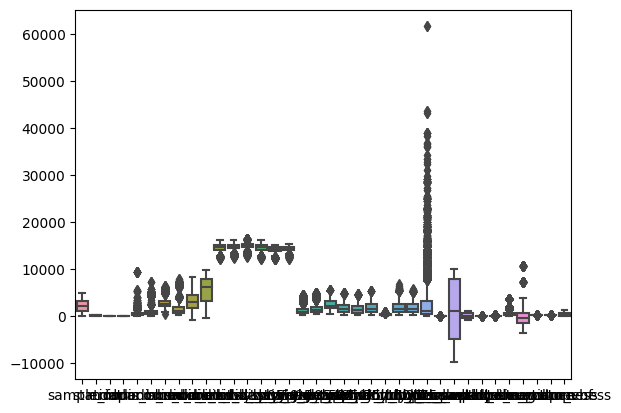

In [17]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


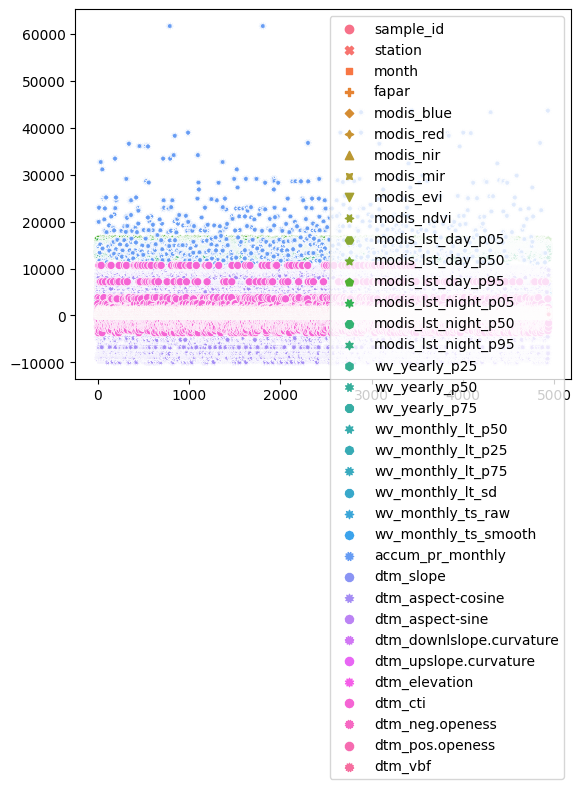

In [18]:
sns.scatterplot(combined)

<Axes: >

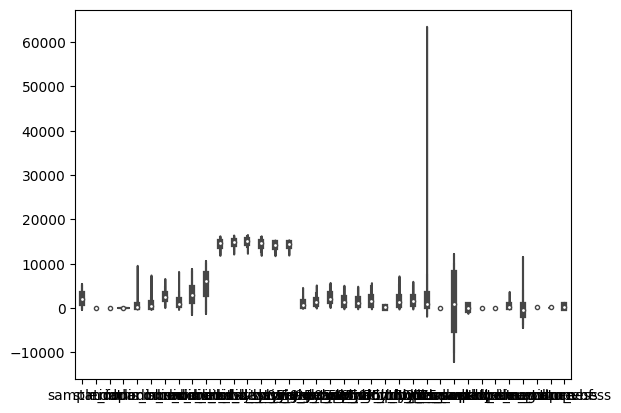

In [19]:
sns.violinplot(combined)

<Axes: ylabel='Density'>

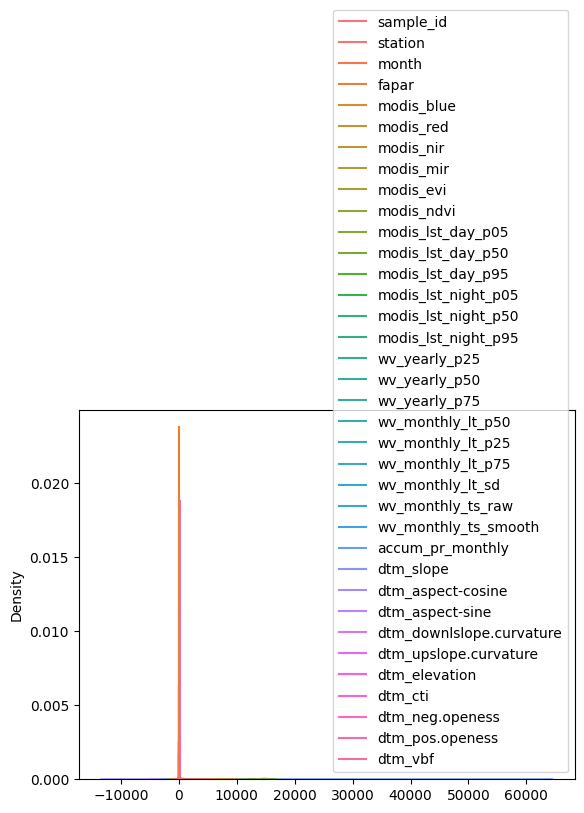

In [20]:

sns.kdeplot(combined)

<Axes: >

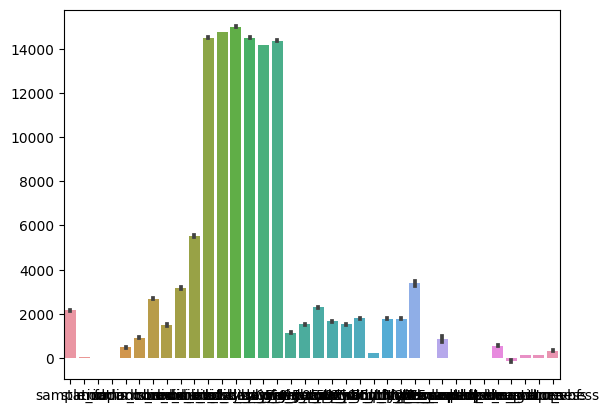

In [21]:
sns.barplot(combined)

<Axes: >

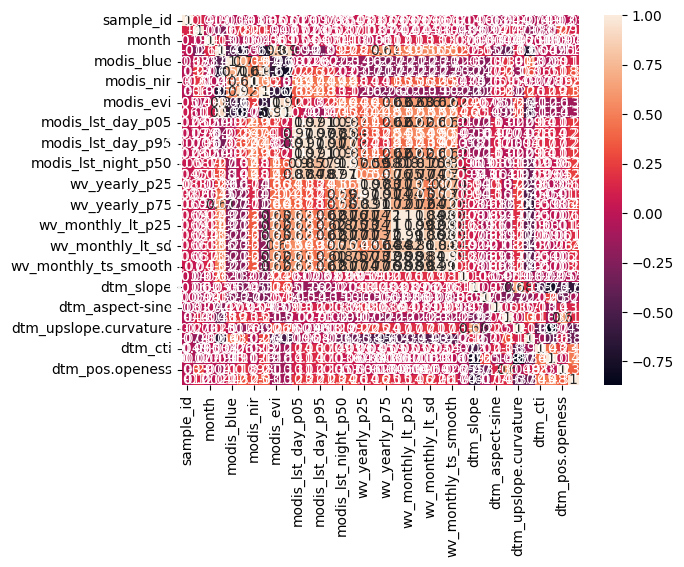

In [22]:
sns.heatmap(combined.corr(),annot=True)

In [24]:
cat_cols = combined.select_dtypes(include='object') 

In [25]:
for i in cat_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*50)

In [26]:
num_cols = combined.select_dtypes(include='number')

In [27]:
for i in  num_cols:
    print(combined[i].value_counts())
    print(i)
    print(''*50)

sample_id
0       2
2312    2
2301    2
2302    2
2303    2
       ..
3951    1
3950    1
3949    1
3948    1
4938    1
Name: count, Length: 4939, dtype: int64
sample_id

station
77    108
82    108
88    108
93    108
83    108
     ... 
72     18
66     18
64     18
65     18
16     15
Name: count, Length: 102, dtype: int64
station

month
9     736
8     732
7     731
10    724
6     716
5     706
11    687
4     687
12    681
3     672
2     664
1     664
Name: count, dtype: int64
month

fapar
0.000000    216
0.004900      6
0.005800      4
0.016100      3
0.063500      3
           ... 
0.958572      1
0.880376      1
0.714792      1
0.845240      1
0.205879      1
Name: count, Length: 3062, dtype: int64
fapar

modis_blue
174.0     43
184.0     38
170.0     36
128.0     36
187.0     35
          ..
2186.0     1
919.0      1
1785.0     1
470.0      1
891.0      1
Name: count, Length: 1218, dtype: int64
modis_blue

modis_red
1431.0    31
235.0     28
219.0     27
232.0     26
262.0  

In [28]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.barplot(data=combined,kde=True,x=i)
    print('\n')
    plt.show()

<Figure size 500x500 with 0 Axes>

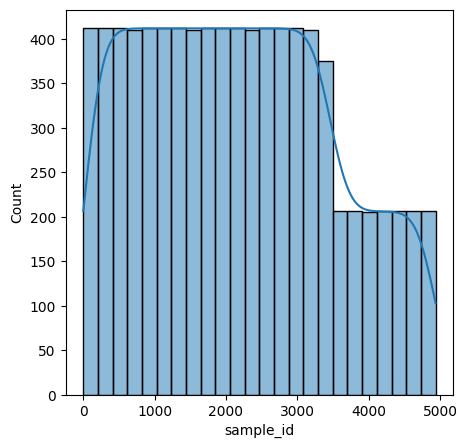

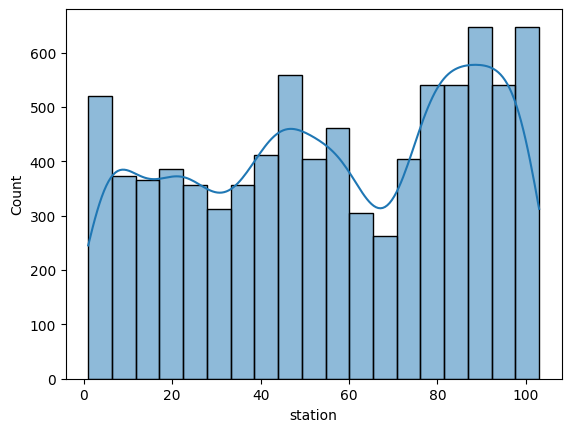

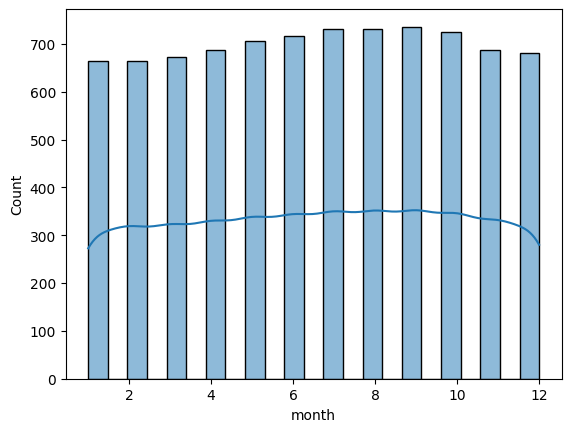

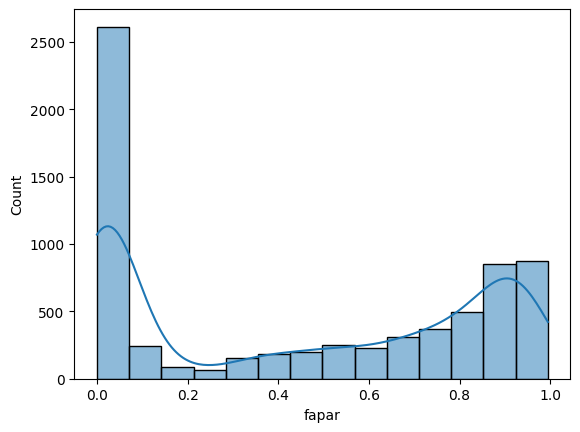

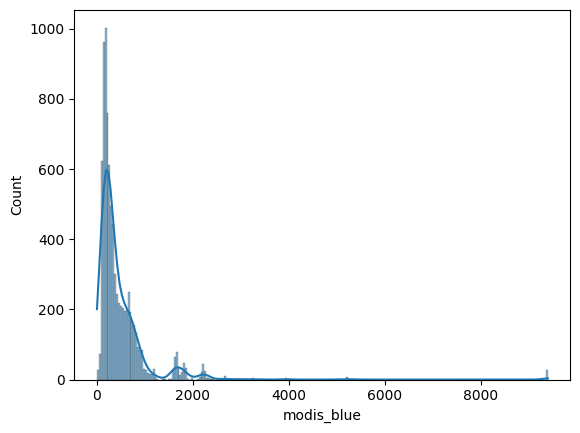

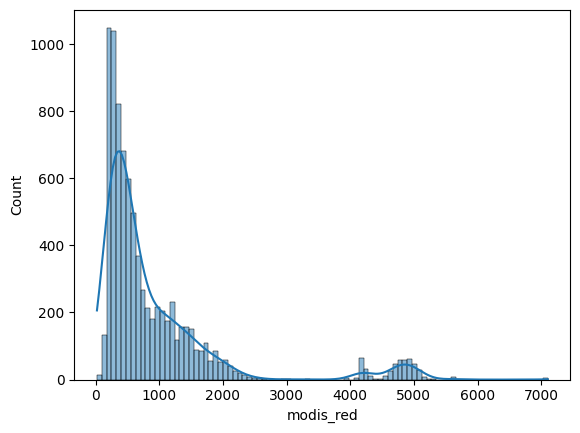

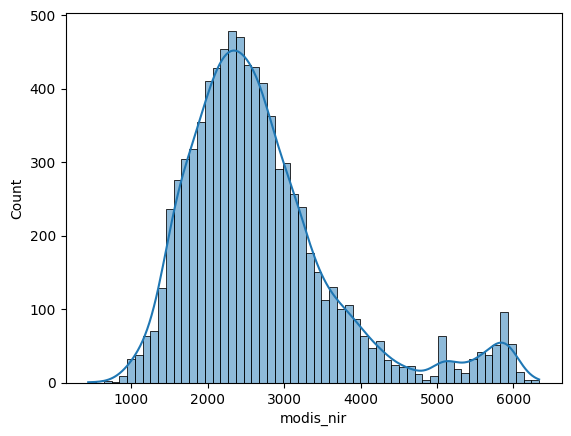

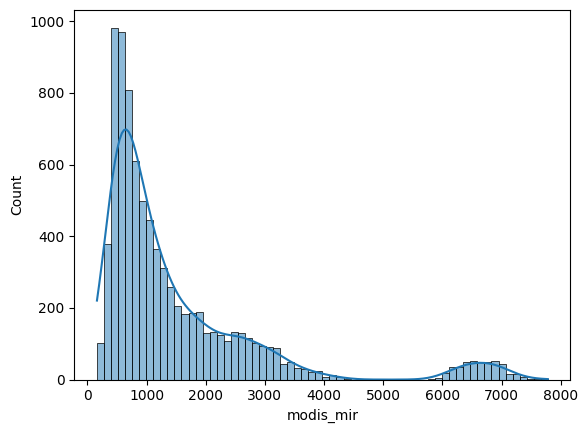

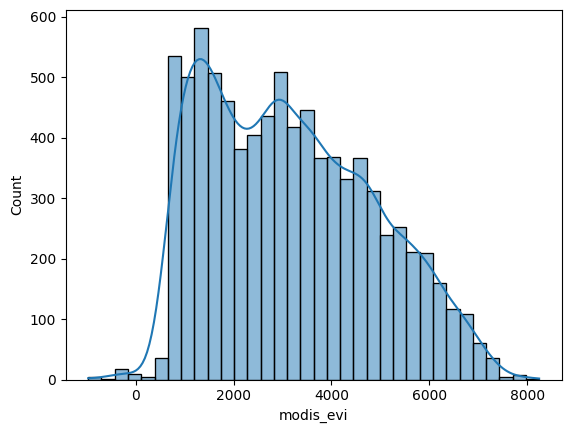

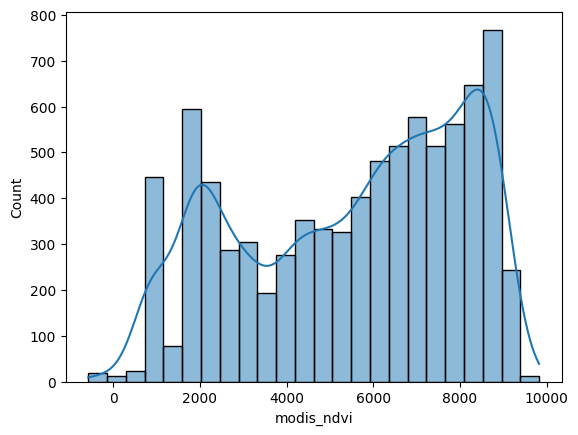

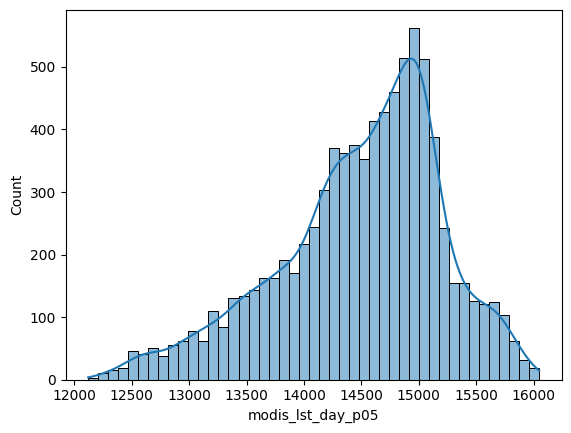

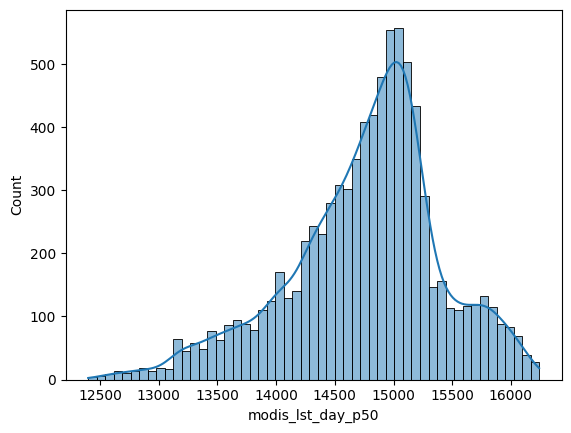

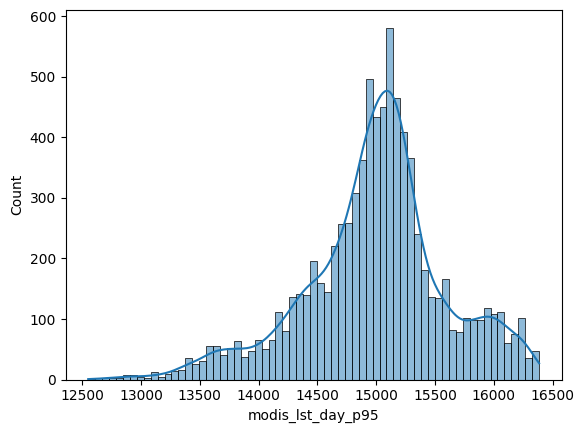

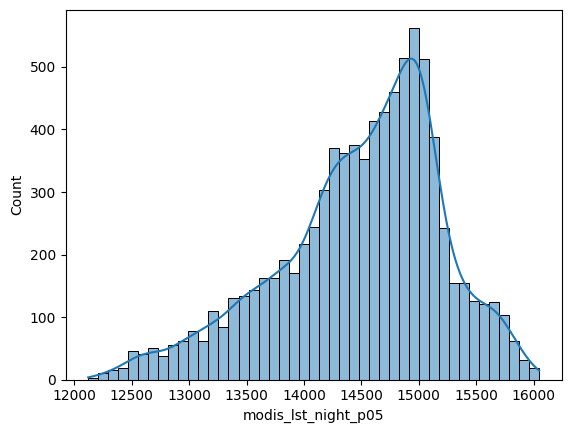

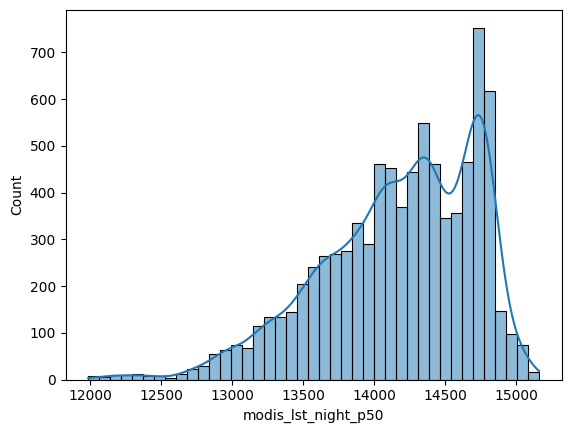

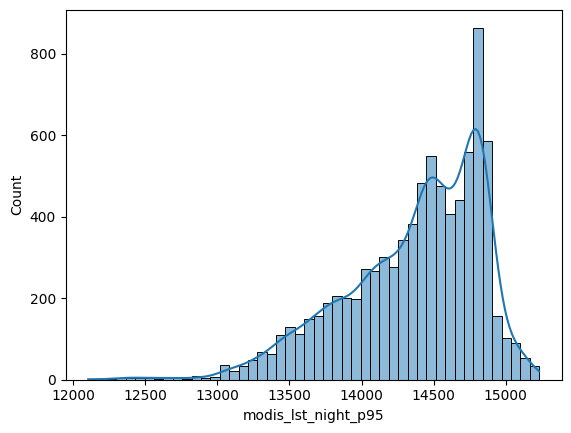

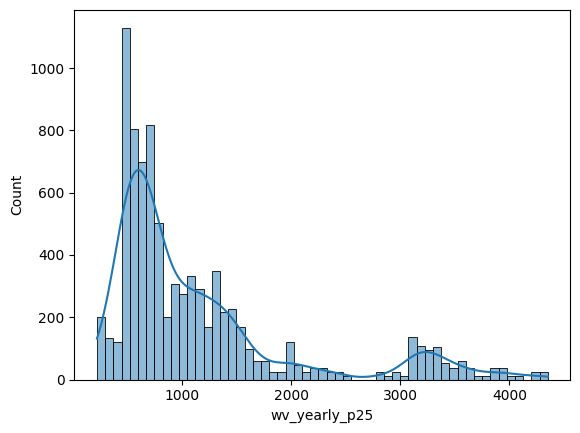

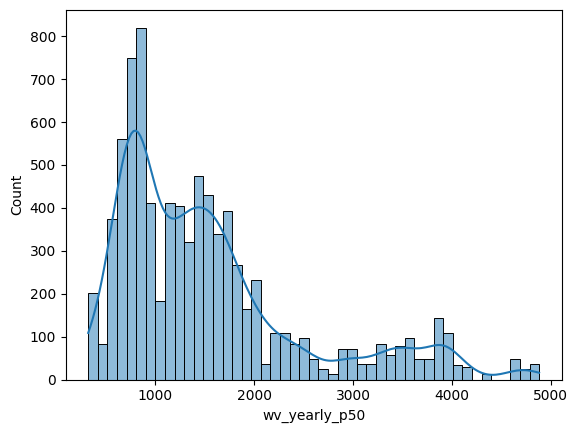

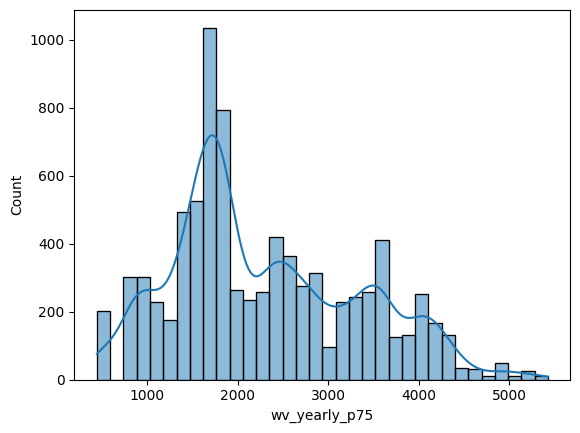

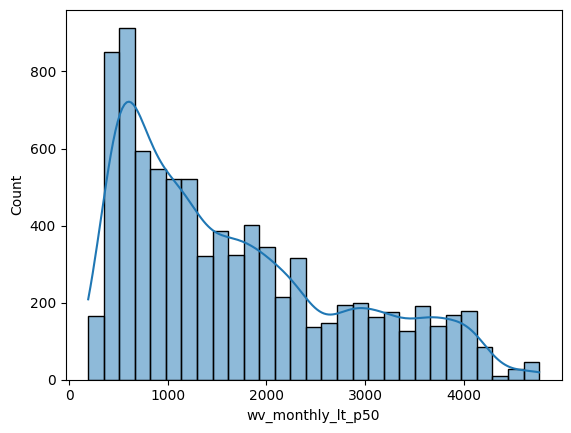

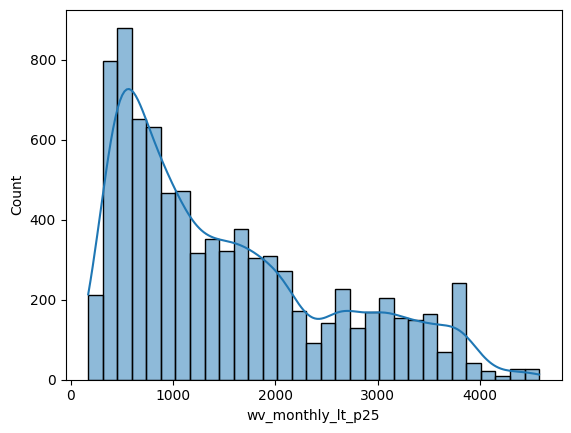

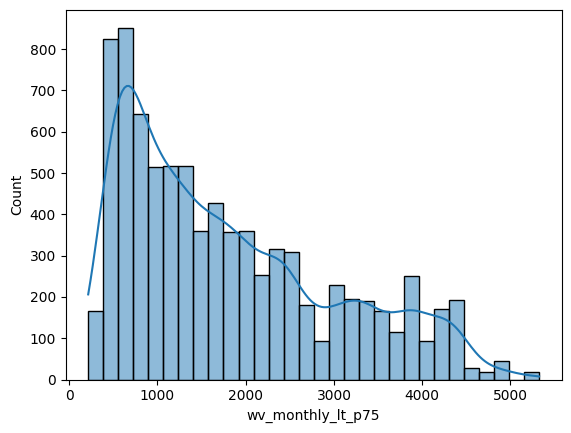

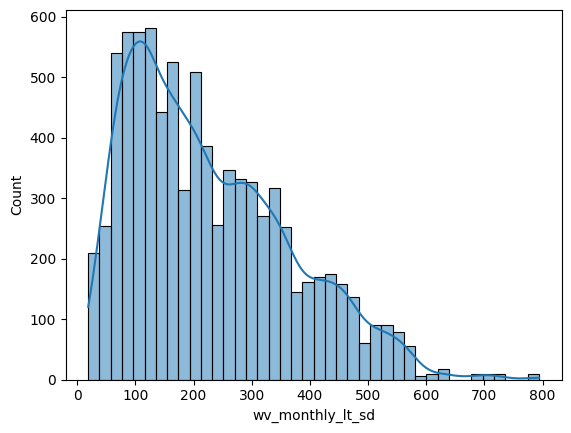

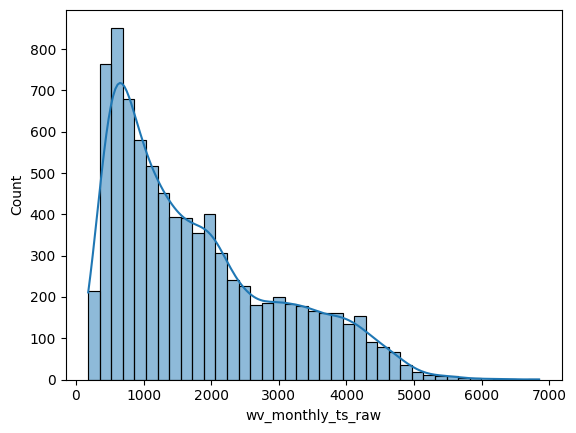

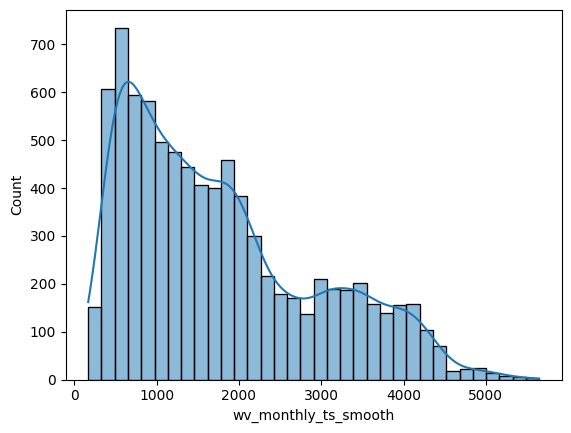

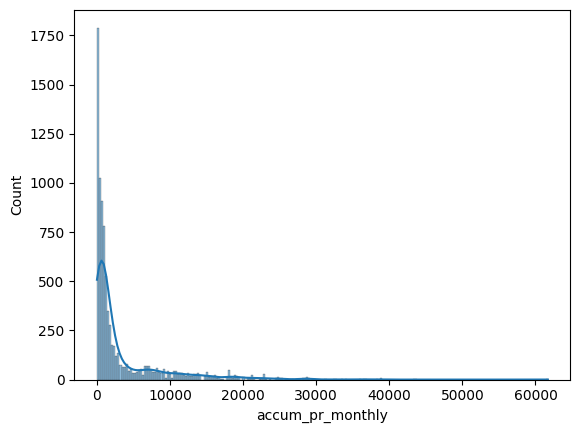

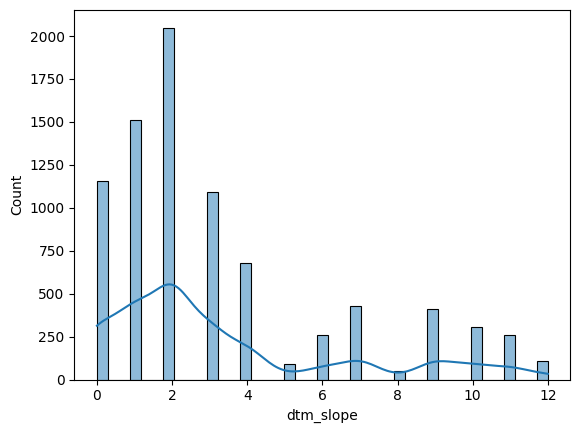

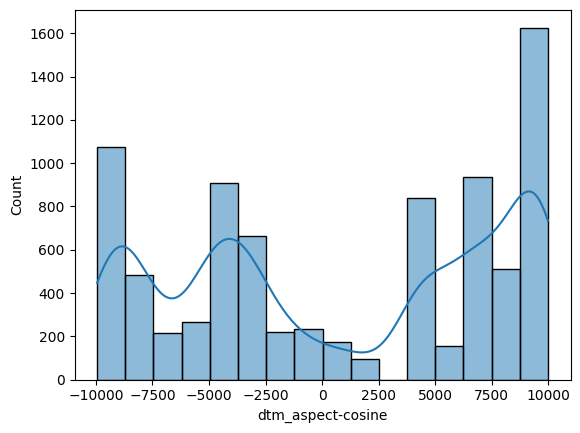

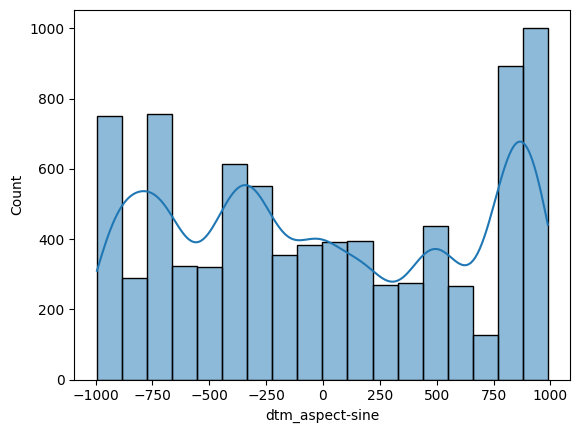

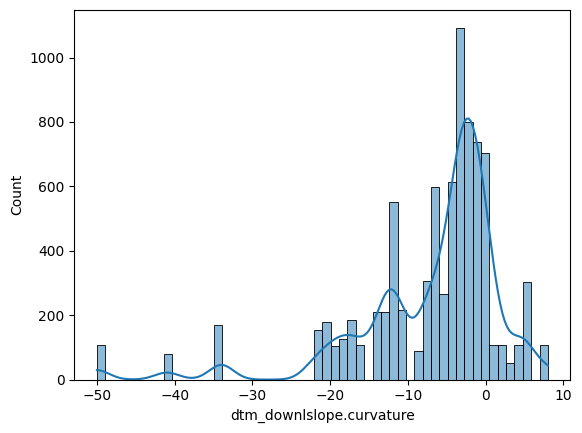

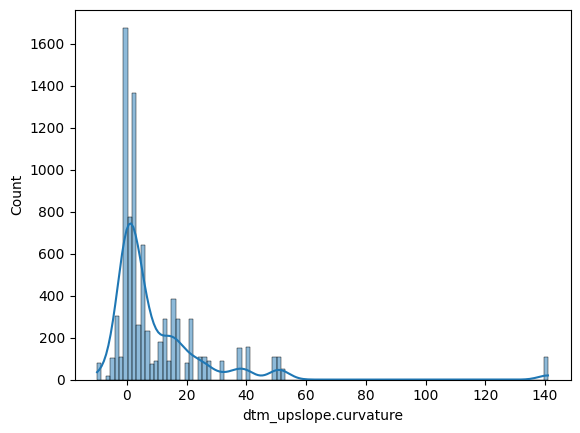

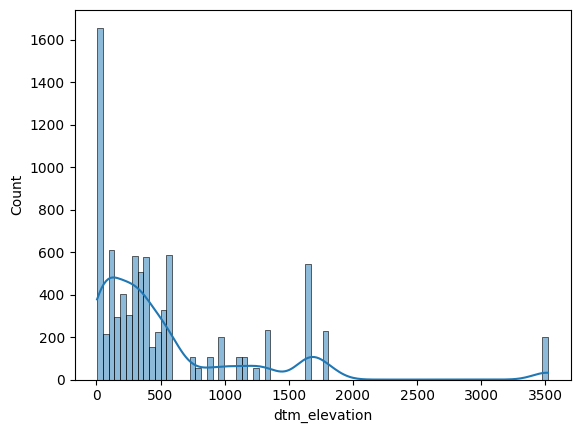

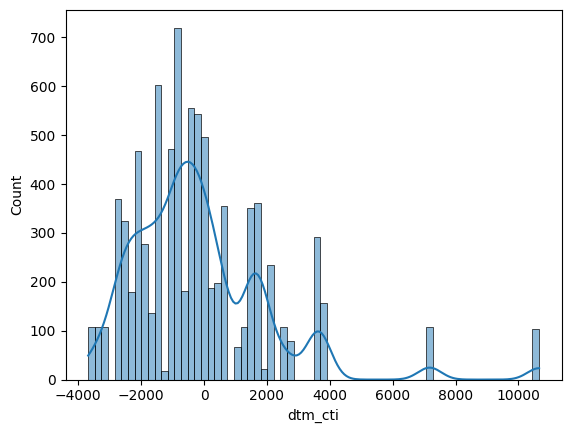

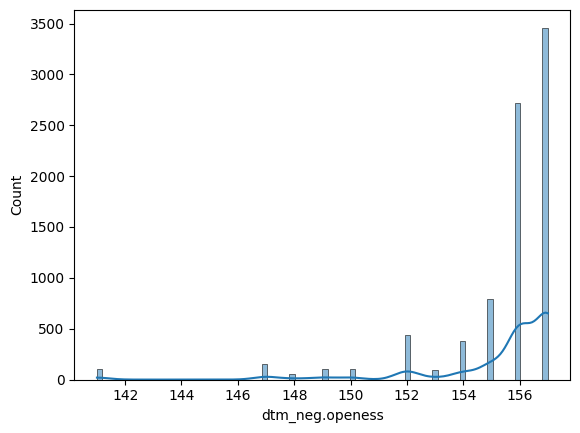

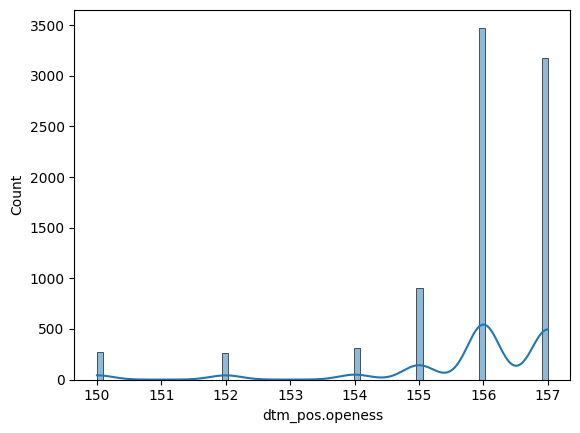

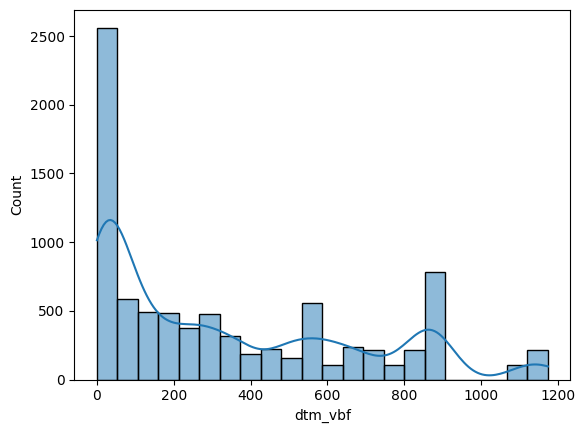

In [29]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,kde=True,x=i)
    print('\n')
    plt.show()

In [30]:
combined['sample_id']=combined['sample_id'].map({"Good":2,"Standard":1,"Poor":0})

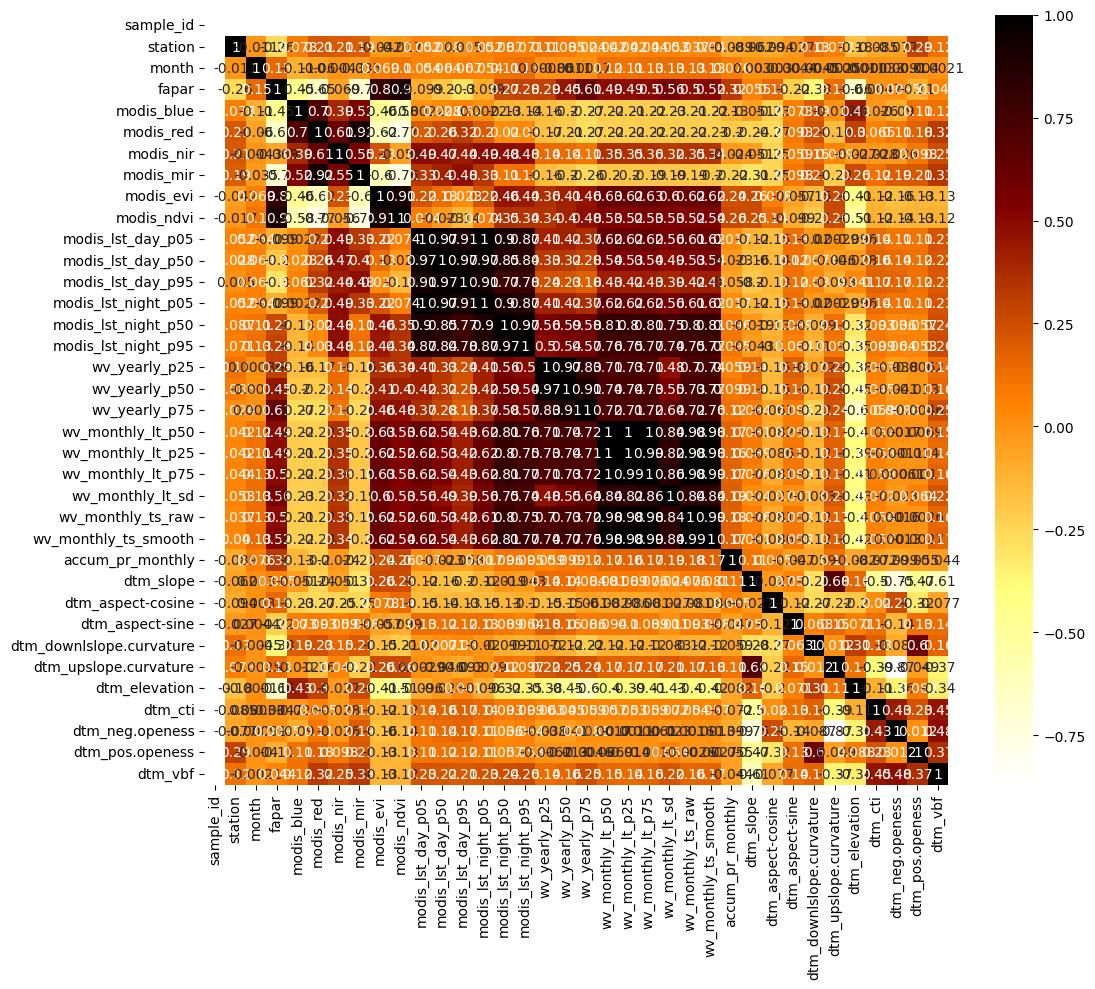

In [31]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


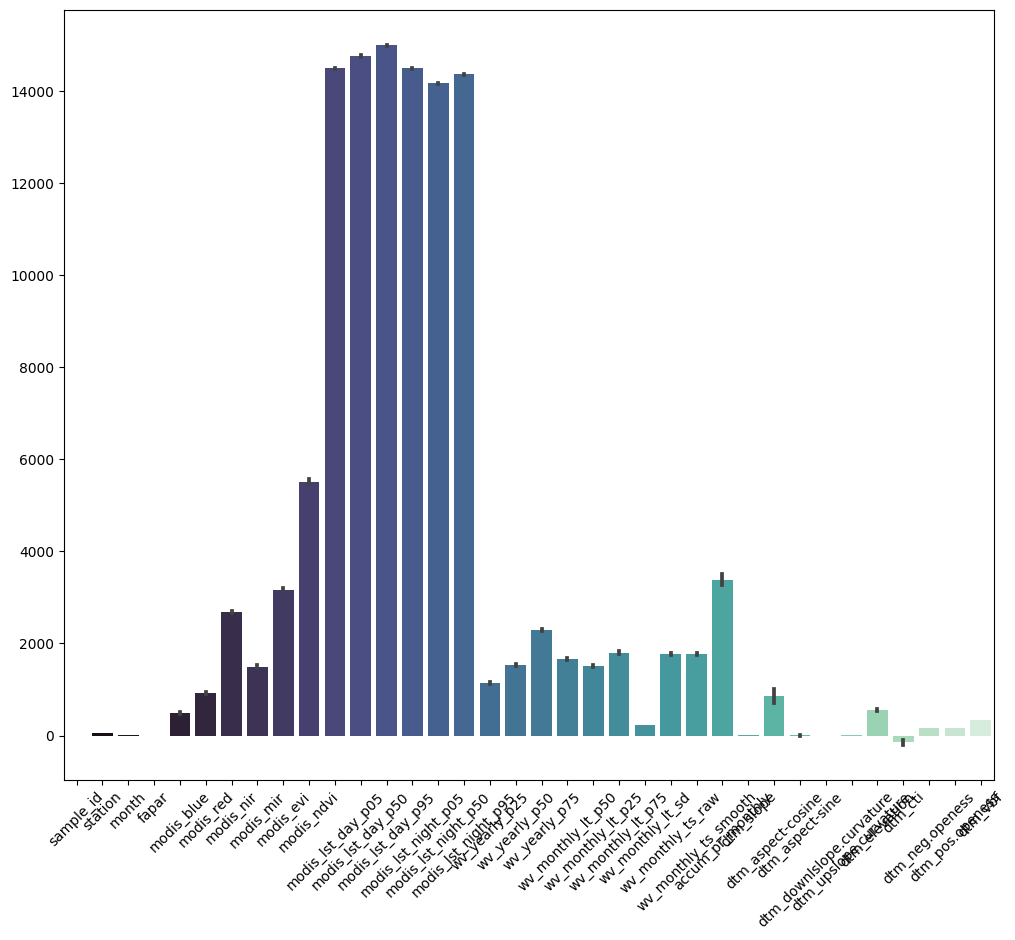

In [32]:
plt.figure(figsize=(12,10))
sns.barplot(combined,palette='mako');
plt.xticks(rotation=45); 

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


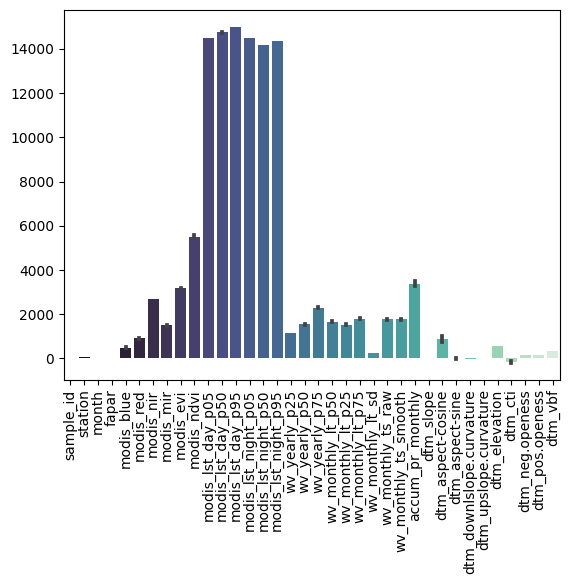

In [33]:
sns.barplot(combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35]),
 [Text(0, 0, 'sample_id'),
  Text(1, 0, 'station'),
  Text(2, 0, 'month'),
  Text(3, 0, 'fapar'),
  Text(4, 0, 'modis_blue'),
  Text(5, 0, 'modis_red'),
  Text(6, 0, 'modis_nir'),
  Text(7, 0, 'modis_mir'),
  Text(8, 0, 'modis_evi'),
  Text(9, 0, 'modis_ndvi'),
  Text(10, 0, 'modis_lst_day_p05'),
  Text(11, 0, 'modis_lst_day_p50'),
  Text(12, 0, 'modis_lst_day_p95'),
  Text(13, 0, 'modis_lst_night_p05'),
  Text(14, 0, 'modis_lst_night_p50'),
  Text(15, 0, 'modis_lst_night_p95'),
  Text(16, 0, 'wv_yearly_p25'),
  Text(17, 0, 'wv_yearly_p50'),
  Text(18, 0, 'wv_yearly_p75'),
  Text(19, 0, 'wv_monthly_lt_p50'),
  Text(20, 0, 'wv_monthly_lt_p25'),
  Text(21, 0, 'wv_monthly_lt_p75'),
  Text(22, 0, 'wv_monthly_lt_sd'),
  Text(23, 0, 'wv_monthly_ts_raw'),
  Text(24, 0, 'wv_monthly_ts_smooth'),
  Text(25, 0, 'accum_pr_monthly'

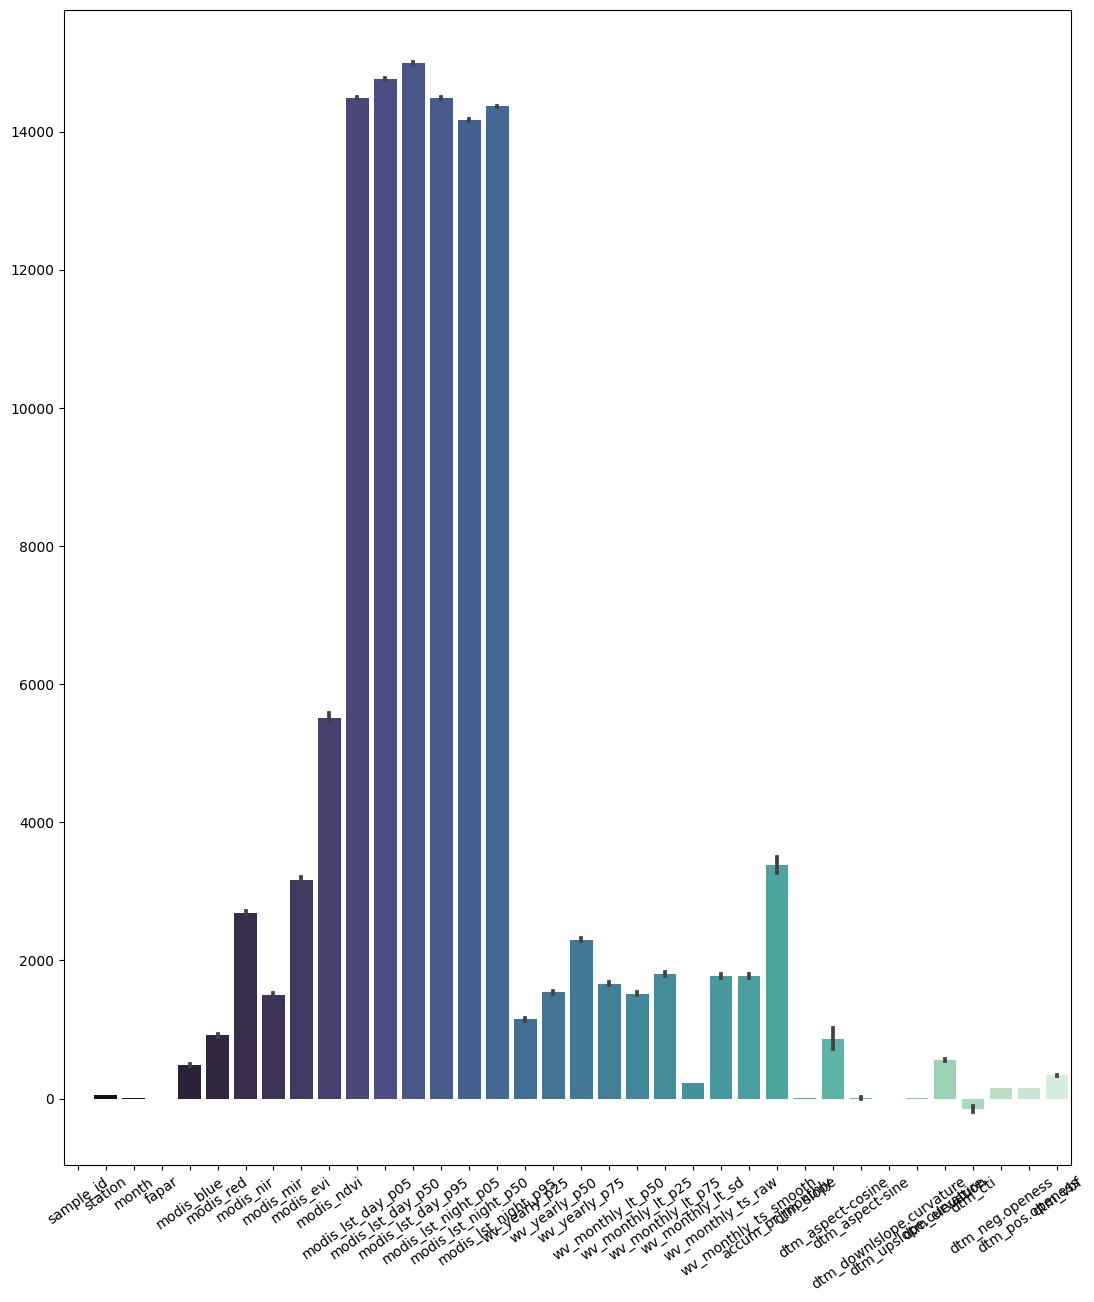

In [34]:
plt.figure(figsize=(13,15))
sns.barplot(combined,palette='mako')
plt.xticks(rotation=35)

In [35]:
combined['sample_id'].value_counts()

Series([], Name: count, dtype: int64)

In [36]:
combined['sample_id'].unique()

array([nan])

<Axes: >

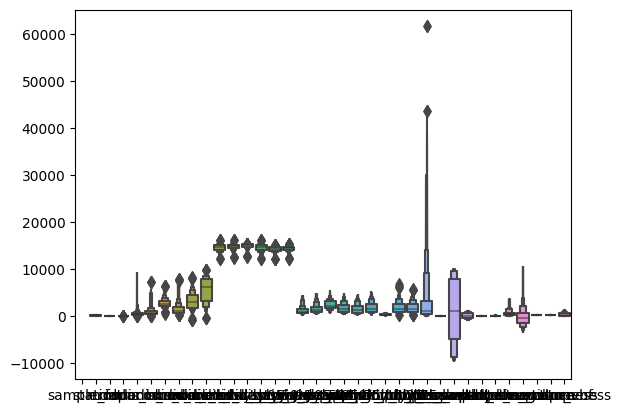

In [37]:
sns.boxenplot(combined)

In [39]:
combined.head()

,sample_id,station,month,fapar,modis_blue,modis_red,modis_nir,modis_mir,modis_evi,modis_ndvi,modis_lst_day_p05,modis_lst_day_p50,modis_lst_day_p95,modis_lst_night_p05,modis_lst_night_p50,modis_lst_night_p95,wv_yearly_p25,wv_yearly_p50,wv_yearly_p75,wv_monthly_lt_p50,wv_monthly_lt_p25,wv_monthly_lt_p75,wv_monthly_lt_sd,wv_monthly_ts_raw,wv_monthly_ts_smooth,accum_pr_monthly,dtm_slope,dtm_aspect-cosine,dtm_aspect-sine,dtm_downlslope.curvature,dtm_upslope.curvature,dtm_elevation,dtm_cti,dtm_neg.openess,dtm_pos.openess,dtm_vbf
0,NaN,52,2,0.310634,235.0,545.0,1306.0,1414.0,1484.0,4108.0,13656.0,14032.0,14384.0,13656.0,13600.0,13760.0,696.0,1531.0,2191.0,513.0,454.0,568.0,123.0,569.0,479.0,8220.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
1,NaN,14,9,0.699500,355.0,531.0,3348.0,786.0,5060.0,7156.0,14904.0,15200.0,15296.0,14904.0,14840.0,14864.0,3179.0,3431.0,3805.0,3915.0,3747.0,4285.0,347.0,4222.0,4081.0,780.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0
2,NaN,52,3,0.353572,276.0,642.0,1496.0,1364.0,1614.0,4086.0,14400.0,14480.0,14888.0,14400.0,13888.0,14112.0,716.0,1223.0,2287.0,625.0,518.0,713.0,135.0,773.0,734.0,383.0,10.0,-4753.0,-876.0,-13.0,13.0,351.0,-2414.0,153.0,155.0,14.0
3,NaN,73,11,0.260067,519.0,1196.0,3256.0,1247.0,3112.0,4628.0,13264.0,13696.0,13976.0,13264.0,13192.0,13664.0,577.0,806.0,1846.0,544.0,503.0,650.0,98.0,640.0,771.0,1358.0,1.0,5685.0,788.0,0.0,0.0,584.0,3795.0,157.0,157.0,257.0
4,NaN,14,3,0.779333,327.0,528.0,3106.0,988.0,4572.0,7048.0,15136.0,15200.0,15296.0,15136.0,14736.0,14800.0,3130.0,3625.0,4024.0,2815.0,2660.0,2974.0,238.0,2977.0,2961.0,1226.0,11.0,-3071.0,945.0,-22.0,40.0,125.0,-412.0,152.0,155.0,10.0


In [40]:
x = combined[['station']]

In [41]:
y = combined[['station']]

In [42]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
lr = LinearRegression()

In [49]:
lr.fit(x_train,y_train)

LinearRegression()

In [52]:
y_pred=lr.predict(x_test)

In [53]:
y_test.head(),y_pred[0:5]

(      station
 4278        2
 1225       47
 1378       12
 1969       85
 1156       67,
 array([[ 2.],
        [47.],
        [12.],
        [85.],
        [67.]]))

In [54]:
from sklearn.metrics import mean_squared_error

In [55]:
mean_squared_error(y_test,y_pred)

8.730819806547119e-29

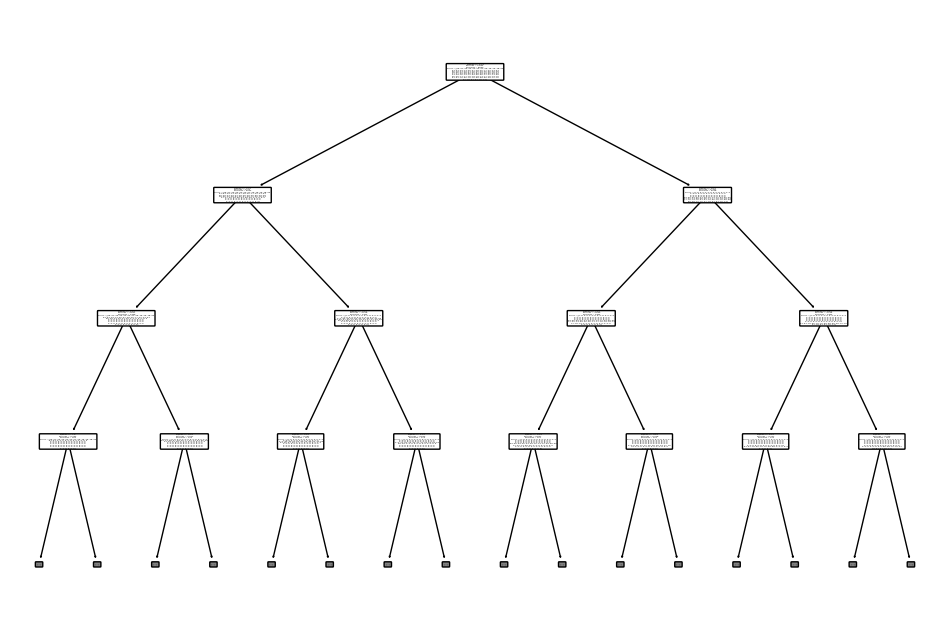

In [58]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

decision_tree_classification = DecisionTreeClassifier(criterion='entropy',random_state=10)
decision_tree = decision_tree_classification.fit(x_train,y_train)

plt.figure(figsize=(12,8))
plot_tree(decision_tree, max_depth=3, feature_names=x_train.columns, rounded=True)
plt.show()

In [60]:
y_pred_test = decision_tree.predict(x_test)
y_pred_train = decision_tree.predict(x_train)
print(decision_tree)

DecisionTreeClassifier(criterion='entropy', random_state=10)


In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00        57
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        52
           5       1.00      1.00      1.00        54
           6       1.00      1.00      1.00        64
           7       1.00      1.00      1.00        57
           8       1.00      1.00      1.00        69
           9       1.00      1.00      1.00        45
          10       1.00      1.00      1.00        29
          11       1.00      1.00      1.00        48
          12       1.00      1.00      1.00        54
          13       1.00      1.00      1.00        54
          14       1.00      1.00      1.00        54
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        14
          17       1.00      1.00      1.00        65
          18       1.00    

In [62]:
print(len(y_train,),len(y_pred_train))

5880 5880


In [66]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

/tmp/ipykernel_32/1408708486.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [67]:
y_pred = model.predict(x_test)
print(classification_report (y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00        28
           7       1.00      1.00      1.00        35
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        23
          10       1.00      1.00      1.00        25
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        22
          15       1.00      1.00      1.00         6
          16       1.00      1.00      1.00         1
          17       1.00      1.00      1.00        25
          18       1.00    